In [2]:
# Run this first if the notebook environment does not already have the packages.
%pip install pandas numpy scipy matplotlib openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from pathlib import Path
import csv
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("default")

DATA_DIR = Path(r"C:\Users\satgu\Downloads\EMG\New folder (3)")
TASK_FILE = DATA_DIR / "Avnish_push1_01.csv"
BASELINE_FILE = DATA_DIR / "Avnish_push1_baselinerest.csv"
LEFT_MVC_FILE = DATA_DIR / "Avnish_push1_leftdynamo_01.csv"
RIGHT_MVC_FILE = DATA_DIR / "Avnish_push1_righydynamo_01.csv"

OUTPUT_DIR = Path(r"C:\Users\satgu\Documents\Code\2026-06-02\files-mentioned-by-the-user-avnish\outputs\emg_graph_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# None for the full recordings.
LOAD_LIMIT_SECONDS = None

FATIGUE_WINDOW_SECONDS = 4.0
FATIGUE_STEP_SECONDS = 2.0
RMS_WINDOW_SECONDS = 1.0
RMS_STEP_SECONDS = 0.25

BANDPASS_LOW_HZ = 20.0
BANDPASS_HIGH_HZ = 450.0
FATIGUE_REF_FIRST_SECONDS = 30.0


In [4]:
import sys
print(sys.executable)


c:\Users\satgu\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [5]:
SENSOR_MAP = {
    "22": {"side": "Right", "region": "Shoulder", "muscle": "Deltoid"},
    "44": {"side": "Right", "region": "Shoulder", "muscle": "Lateral head of triceps"},
    "66": {"side": "Right", "region": "Shoulder", "muscle": "Upper trap"},
    "33": {"side": "Right", "region": "Shoulder", "muscle": "Supraspinatus"},
    "11": {"side": "Left", "region": "Shoulder", "muscle": "Supraspinatus"},
    "12": {"side": "Left", "region": "Shoulder", "muscle": "Deltoid"},
    "88": {"side": "Left", "region": "Shoulder", "muscle": "Lateral head of triceps"},
    "99": {"side": "Left", "region": "Shoulder", "muscle": "Traps"},
    "1": {"side": "Left", "region": "Forearm", "muscle": "Forearm 1"},
    "2": {"side": "Left", "region": "Forearm", "muscle": "Forearm 2"},
    "3": {"side": "Left", "region": "Forearm", "muscle": "Forearm 3"},
    "4": {"side": "Left", "region": "Forearm", "muscle": "Forearm 4"},
    "5": {"side": "Right", "region": "Forearm", "muscle": "Forearm 5"},
    "6": {"side": "Right", "region": "Forearm", "muscle": "Forearm 6"},
    "7": {"side": "Right", "region": "Forearm", "muscle": "Forearm 7"},
    "8": {"side": "Right", "region": "Forearm", "muscle": "Forearm 8"},
}

GROUP_ORDER = ["Right Shoulder", "Left Shoulder", "Right Forearm", "Left Forearm"]
GROUP_COLORS = {
    "Right Shoulder": "#1f77b4",
    "Left Shoulder": "#d62728",
    "Right Forearm": "#2ca02c",
    "Left Forearm": "#9467bd",
}


def sensor_label(sensor_id):
    meta = SENSOR_MAP[str(sensor_id)]
    return f"{meta['side']} {meta['region']} - {meta['muscle']} (Sensor {sensor_id})"


def group_label(sensor_id):
    meta = SENSOR_MAP[str(sensor_id)]
    return f"{meta['side']} {meta['region']}"


In [6]:
def read_trigno_metadata(path):
    path = Path(path)
    with path.open(newline="", encoding="utf-8-sig", errors="replace") as f:
        reader = csv.reader(f)
        rows = [next(reader) for _ in range(8)]

    sensors = {}
    for col_idx, value in enumerate(rows[3]):
        match = re.search(r"Avanti Sensor\s+(\d+)", value)
        if not match:
            continue

        sensor_id = match.group(1)
        fs_text = rows[6][col_idx + 1] if col_idx + 1 < len(rows[6]) else ""
        dt_text = rows[7][col_idx + 1] if col_idx + 1 < len(rows[7]) else ""

        fs_match = re.search(r"([0-9.]+)", fs_text)
        dt_match = re.search(r"([0-9.]+)", dt_text)

        sensors[sensor_id] = {
            "label": value.strip(),
            "time_col": col_idx,
            "emg_col": col_idx + 1,
            "fs": float(fs_match.group(1)) if fs_match else np.nan,
            "dt": float(dt_match.group(1)) if dt_match else np.nan,
        }

    return sensors


def load_emg_csv(path, sensor_ids=None, limit_seconds=None):
    path = Path(path)
    metadata = read_trigno_metadata(path)

    if sensor_ids is None:
        sensor_ids = list(metadata.keys())
    sensor_ids = [str(sensor_id) for sensor_id in sensor_ids if str(sensor_id) in metadata]
    sensor_ids = sorted(sensor_ids, key=lambda sensor_id: metadata[sensor_id]["time_col"])

    usecols = []
    names = []
    for sensor_id in sensor_ids:
        info = metadata[sensor_id]
        usecols.extend([info["time_col"], info["emg_col"]])
        names.extend([f"t_{sensor_id}", f"emg_{sensor_id}"])

    nrows = None
    if limit_seconds is not None:
        fs_values = [metadata[sensor_id]["fs"] for sensor_id in sensor_ids if np.isfinite(metadata[sensor_id]["fs"])]
        approx_fs = max(fs_values) if fs_values else 1260
        nrows = int(limit_seconds * approx_fs) + 10

    df = pd.read_csv(
        path,
        skiprows=8,
        header=None,
        usecols=usecols,
        nrows=nrows,
        skipinitialspace=True,
        na_values=["", " "],
        engine="c",
    )
    df.columns = names

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("float32")

    return df, metadata


def extract_sensor_arrays(df, sensor_id):
    sensor_id = str(sensor_id)
    time = df[f"t_{sensor_id}"].to_numpy(dtype=float)
    values = df[f"emg_{sensor_id}"].to_numpy(dtype=float)
    mask = np.isfinite(time) & np.isfinite(values)
    return time[mask], values[mask]


In [7]:
def bandpass_emg(values, fs, low_hz=None, high_hz=None, order=4):
    if low_hz is None:
        low_hz = globals().get("BANDPASS_LOW_HZ", 20.0)
    if high_hz is None:
        high_hz = globals().get("BANDPASS_HIGH_HZ", 450.0)

    x = np.asarray(values, dtype=float)
    finite = np.isfinite(x)
    if not finite.any():
        return np.zeros_like(x, dtype=float)

    fill_value = np.nanmedian(x[finite])
    x = np.where(finite, x, fill_value)
    x = x - np.mean(x)

    nyquist = fs / 2.0
    high_hz = min(high_hz, nyquist * 0.95)
    if low_hz >= high_hz or len(x) < max(16, order * 8):
        return x

    sos = signal.butter(order, [low_hz, high_hz], btype="bandpass", fs=fs, output="sos")
    try:
        return signal.sosfiltfilt(sos, x)
    except ValueError:
        warnings.warn("Signal too short for zero-phase filtering; using forward filter for this channel.")
        return signal.sosfilt(sos, x)


def window_starts(n_samples, window_samples, step_samples):
    if n_samples == 0:
        return np.array([], dtype=int)
    window_samples = min(window_samples, n_samples)
    return np.arange(0, n_samples - window_samples + 1, step_samples, dtype=int)


def windowed_rms(time, values, fs, window_seconds=None, step_seconds=None):
    if window_seconds is None:
        window_seconds = globals().get("RMS_WINDOW_SECONDS", 1.0)
    if step_seconds is None:
        step_seconds = globals().get("RMS_STEP_SECONDS", 0.25)

    values = np.asarray(values, dtype=float)
    time = np.asarray(time, dtype=float)
    win = max(1, int(round(window_seconds * fs)))
    step = max(1, int(round(step_seconds * fs)))
    starts = window_starts(len(values), win, step)

    centers = []
    rms_values = []
    for start in starts:
        end = min(start + win, len(values))
        segment = values[start:end]
        if len(segment) == 0:
            continue
        centers.append((time[start] + time[end - 1]) / 2.0)
        rms_values.append(np.sqrt(np.mean(segment ** 2)))

    return np.asarray(centers), np.asarray(rms_values)


def median_frequency_from_psd(freqs, psd):
    total_power = np.sum(psd)
    if total_power <= 0 or len(freqs) == 0:
        return np.nan
    cumulative = np.cumsum(psd)
    return freqs[np.searchsorted(cumulative, total_power / 2.0)]


def mean_frequency_from_psd(freqs, psd):
    total_power = np.sum(psd)
    if total_power <= 0 or len(freqs) == 0:
        return np.nan
    return np.sum(freqs * psd) / total_power


def sliding_frequency_features(
    time,
    values,
    fs,
    window_seconds=None,
    step_seconds=None,
    fmin=None,
    fmax=None,
):
    if window_seconds is None:
        window_seconds = globals().get("FATIGUE_WINDOW_SECONDS", 4.0)
    if step_seconds is None:
        step_seconds = globals().get("FATIGUE_STEP_SECONDS", 2.0)
    if fmin is None:
        fmin = globals().get("BANDPASS_LOW_HZ", 20.0)
    if fmax is None:
        fmax = globals().get("BANDPASS_HIGH_HZ", 450.0)

    values = np.asarray(values, dtype=float)
    time = np.asarray(time, dtype=float)
    win = max(1, int(round(window_seconds * fs)))
    step = max(1, int(round(step_seconds * fs)))
    starts = window_starts(len(values), win, step)

    rows = []
    for start in starts:
        end = min(start + win, len(values))
        segment = values[start:end]
        if len(segment) < max(8, int(0.5 * fs)):
            continue

        nperseg = min(len(segment), int(round(1.0 * fs)))
        freqs, psd = signal.welch(segment, fs=fs, nperseg=nperseg, detrend="constant")
        valid = (freqs >= fmin) & (freqs <= min(fmax, fs / 2.0 * 0.95))
        freqs = freqs[valid]
        psd = psd[valid]

        center_time = (time[start] + time[end - 1]) / 2.0
        rows.append(
            {
                "time_s": center_time,
                "mdf_hz": median_frequency_from_psd(freqs, psd),
                "mnf_hz": mean_frequency_from_psd(freqs, psd),
                "rms_mV": np.sqrt(np.mean(segment ** 2)),
            }
        )

    return pd.DataFrame(rows)


def prepared_filtered_signal(df, metadata, sensor_id):
    sensor_id = str(sensor_id)
    time, raw = extract_sensor_arrays(df, sensor_id)
    fs = metadata[sensor_id]["fs"]
    filtered = bandpass_emg(raw, fs)
    return time, filtered, fs


In [8]:
SENSORS_TO_ANALYZE = [sensor_id for sensor_id in SENSOR_MAP.keys()]

task_df, task_meta = load_emg_csv(TASK_FILE, SENSORS_TO_ANALYZE, limit_seconds=LOAD_LIMIT_SECONDS)
baseline_df, baseline_meta = load_emg_csv(BASELINE_FILE, SENSORS_TO_ANALYZE, limit_seconds=LOAD_LIMIT_SECONDS)
left_mvc_df, left_mvc_meta = load_emg_csv(LEFT_MVC_FILE, SENSORS_TO_ANALYZE, limit_seconds=LOAD_LIMIT_SECONDS)
right_mvc_df, right_mvc_meta = load_emg_csv(RIGHT_MVC_FILE, SENSORS_TO_ANALYZE, limit_seconds=LOAD_LIMIT_SECONDS)

print("Loaded shapes:")
print("Task:", task_df.shape)
print("Baseline:", baseline_df.shape)
print("Left MVC:", left_mvc_df.shape)
print("Right MVC:", right_mvc_df.shape)
print(f"Figures and CSV outputs will be saved to: {OUTPUT_DIR}")


Loaded shapes:
Task: (463420, 32)
Baseline: (379355, 32)
Left MVC: (75973, 32)
Right MVC: (61948, 32)
Figures and CSV outputs will be saved to: C:\Users\satgu\Documents\Code\2026-06-02\files-mentioned-by-the-user-avnish\outputs\emg_graph_outputs


In [9]:
def compute_fatigue_table(task_df, task_meta):
    all_rows = []

    for sensor_id in SENSORS_TO_ANALYZE:
        if sensor_id not in task_meta:
            continue

        time, filtered, fs = prepared_filtered_signal(task_df, task_meta, sensor_id)
        features = sliding_frequency_features(time, filtered, fs)
        if features.empty:
            continue

        ref_mask = features["time_s"] <= FATIGUE_REF_FIRST_SECONDS
        mdf_reference = features.loc[ref_mask, "mdf_hz"].median()
        if not np.isfinite(mdf_reference) or mdf_reference <= 0:
            mdf_reference = features["mdf_hz"].head(5).median()

        mnf_reference = features.loc[ref_mask, "mnf_hz"].median()
        if not np.isfinite(mnf_reference) or mnf_reference <= 0:
            mnf_reference = features["mnf_hz"].head(5).median()

        features["mdf_norm_pct"] = 100.0 * features["mdf_hz"] / mdf_reference
        features["mnf_norm_pct"] = 100.0 * features["mnf_hz"] / mnf_reference
        features["sensor"] = sensor_id
        features["muscle"] = SENSOR_MAP[sensor_id]["muscle"]
        features["side"] = SENSOR_MAP[sensor_id]["side"]
        features["region"] = SENSOR_MAP[sensor_id]["region"]
        features["group"] = features["side"] + " " + features["region"]
        features["label"] = sensor_label(sensor_id)
        all_rows.append(features)

    fatigue = pd.concat(all_rows, ignore_index=True)
    return fatigue


def slope_per_minute(df, value_col):
    valid = df[["time_s", value_col]].dropna()
    if len(valid) < 3:
        return np.nan
    return np.polyfit(valid["time_s"].to_numpy() / 60.0, valid[value_col].to_numpy(), 1)[0]


fatigue_df = compute_fatigue_table(task_df, task_meta)

fatigue_summary_rows = []
for (sensor, label, group), sensor_data in fatigue_df.groupby(["sensor", "label", "group"]):
    sensor_data = sensor_data.sort_values("time_s")
    fatigue_summary_rows.append(
        {
            "sensor": sensor,
            "label": label,
            "group": group,
            "mdf_start_hz": sensor_data["mdf_hz"].head(5).mean(),
            "mdf_end_hz": sensor_data["mdf_hz"].tail(5).mean(),
            "mdf_slope_hz_per_min": slope_per_minute(sensor_data, "mdf_hz"),
            "mnf_start_hz": sensor_data["mnf_hz"].head(5).mean(),
            "mnf_end_hz": sensor_data["mnf_hz"].tail(5).mean(),
            "mnf_slope_hz_per_min": slope_per_minute(sensor_data, "mnf_hz"),
            "mdf_start_pct": sensor_data["mdf_norm_pct"].head(5).mean(),
            "mdf_end_pct": sensor_data["mdf_norm_pct"].tail(5).mean(),
            "mdf_slope_pct_per_min": slope_per_minute(sensor_data, "mdf_norm_pct"),
            "mnf_start_pct": sensor_data["mnf_norm_pct"].head(5).mean(),
            "mnf_end_pct": sensor_data["mnf_norm_pct"].tail(5).mean(),
            "mnf_slope_pct_per_min": slope_per_minute(sensor_data, "mnf_norm_pct"),
        }
    )

fatigue_summary = pd.DataFrame(fatigue_summary_rows)

fatigue_df.to_csv(OUTPUT_DIR / "fatigue_window_features.csv", index=False)
fatigue_summary.to_csv(OUTPUT_DIR / "fatigue_summary_by_sensor.csv", index=False)

display(fatigue_summary.sort_values("mdf_slope_hz_per_min").round(3))


,sensor,label,group,mdf_start_hz,mdf_end_hz,mdf_slope_hz_per_min,mnf_start_hz,mnf_end_hz,mnf_slope_hz_per_min,mdf_start_pct,mdf_end_pct,mdf_slope_pct_per_min,mnf_start_pct,mnf_end_pct,mnf_slope_pct_per_min
15,99,Left Shoulder - Traps (Sensor 99),Left Shoulder,67.814,63.413,-1.716,78.052,66.463,-1.968,94.167,88.056,-2.383,98.434,83.819,-2.482
4,22,Right Shoulder - Deltoid (Sensor 22),Right Shoulder,82.417,75.416,-1.626,91.752,86.707,-1.297,99.277,90.843,-1.959,97.565,92.200,-1.379
2,12,Left Shoulder - Deltoid (Sensor 12),Left Shoulder,68.614,62.813,-0.784,76.329,68.936,-0.923,103.158,94.436,-1.179,103.930,93.863,-1.257
3,2,Left Forearm - Forearm 2 (Sensor 2),Left Forearm,75.215,71.215,-0.331,98.950,84.898,-0.743,98.947,93.684,-0.436,108.282,92.905,-0.813
14,88,Left Shoulder - Lateral head of triceps (Senso...,Left Shoulder,68.014,59.812,-0.219,86.950,76.428,-0.373,117.241,103.103,-0.377,117.553,103.327,-0.504
8,44,Right Shoulder - Lateral head of triceps (Sens...,Right Shoulder,62.813,60.212,-0.156,80.528,69.947,-0.694,104.667,100.333,-0.260,110.277,95.788,-0.950
1,11,Left Shoulder - Supraspinatus (Sensor 11),Left Shoulder,65.013,54.211,-0.111,85.263,71.540,-0.280,101.562,84.688,-0.174,107.808,90.457,-0.354
6,33,Right Shoulder - Supraspinatus (Sensor 33),Right Shoulder,82.417,83.617,-0.101,105.402,101.782,-0.149,95.814,97.209,-0.118,101.545,98.058,-0.143
5,3,Left Forearm - Forearm 3 (Sensor 3),Left Forearm,76.616,70.815,0.151,100.901,86.870,-0.561,109.429,101.143,0.216,117.888,101.495,-0.655
11,66,Right Shoulder - Upper trap (Sensor 66),Right Shoulder,66.814,67.214,0.152,74.576,70.541,-0.573,99.701,100.299,0.227,101.109,95.637,-0.777


Saved: C:\Users\satgu\Documents\Code\2026-06-02\files-mentioned-by-the-user-avnish\outputs\emg_graph_outputs\fatigue_mdf_mnf_overall_trend.png


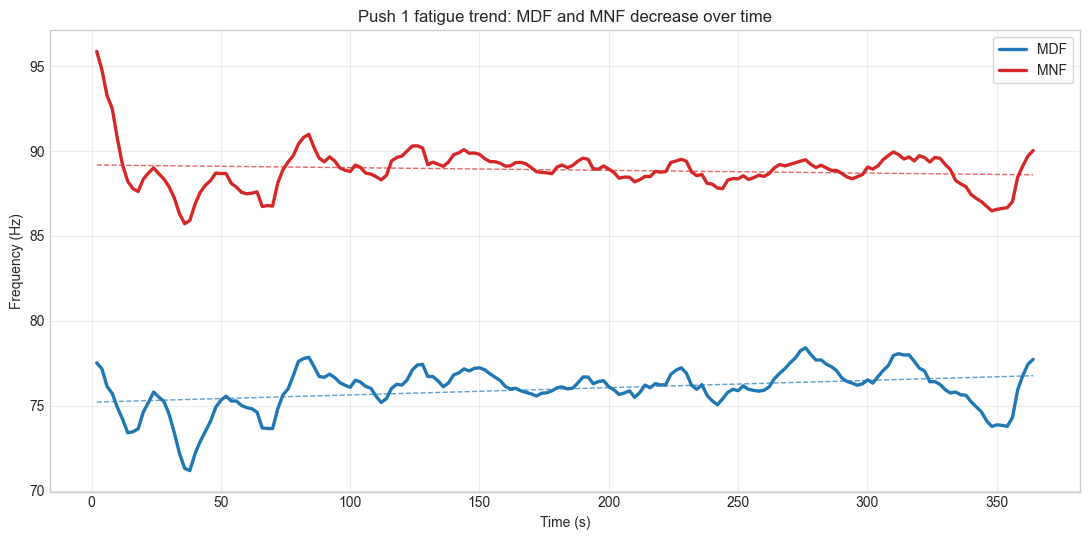

Saved: C:\Users\satgu\Documents\Code\2026-06-02\files-mentioned-by-the-user-avnish\outputs\emg_graph_outputs\fatigue_mdf_mnf_group_trends.png


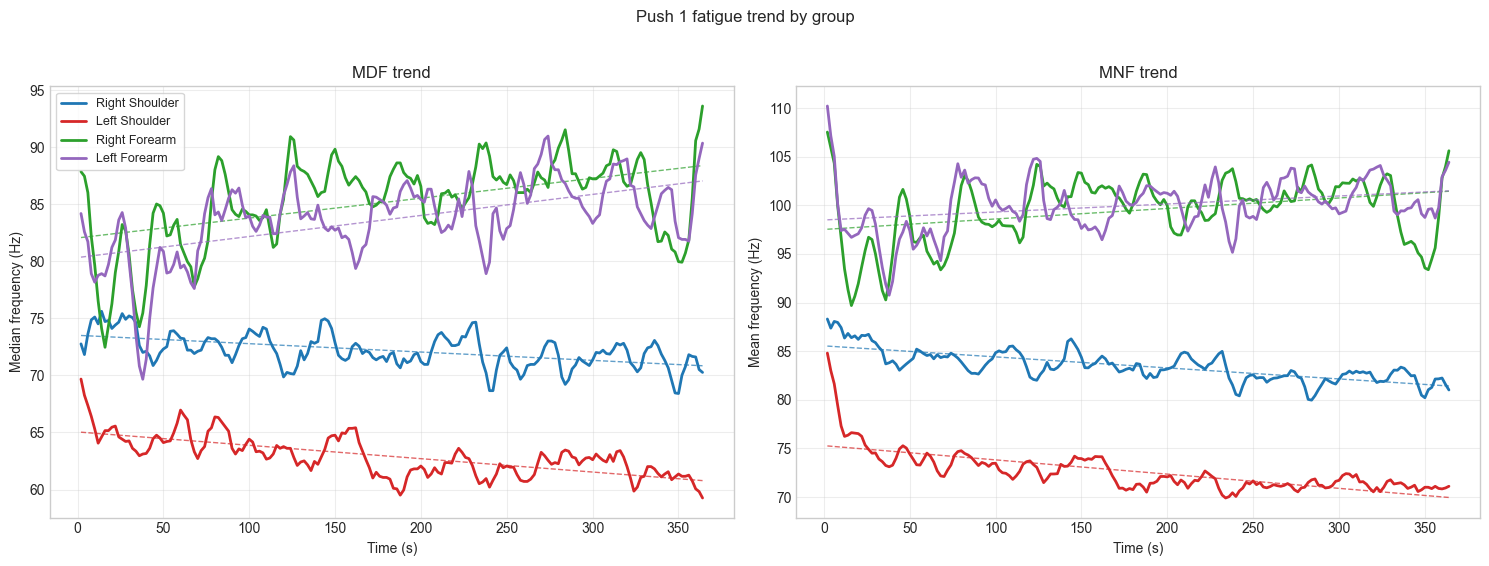

Saved: C:\Users\satgu\Documents\Code\2026-06-02\files-mentioned-by-the-user-avnish\outputs\emg_graph_outputs\fatigue_mdf_individual_sensors.png


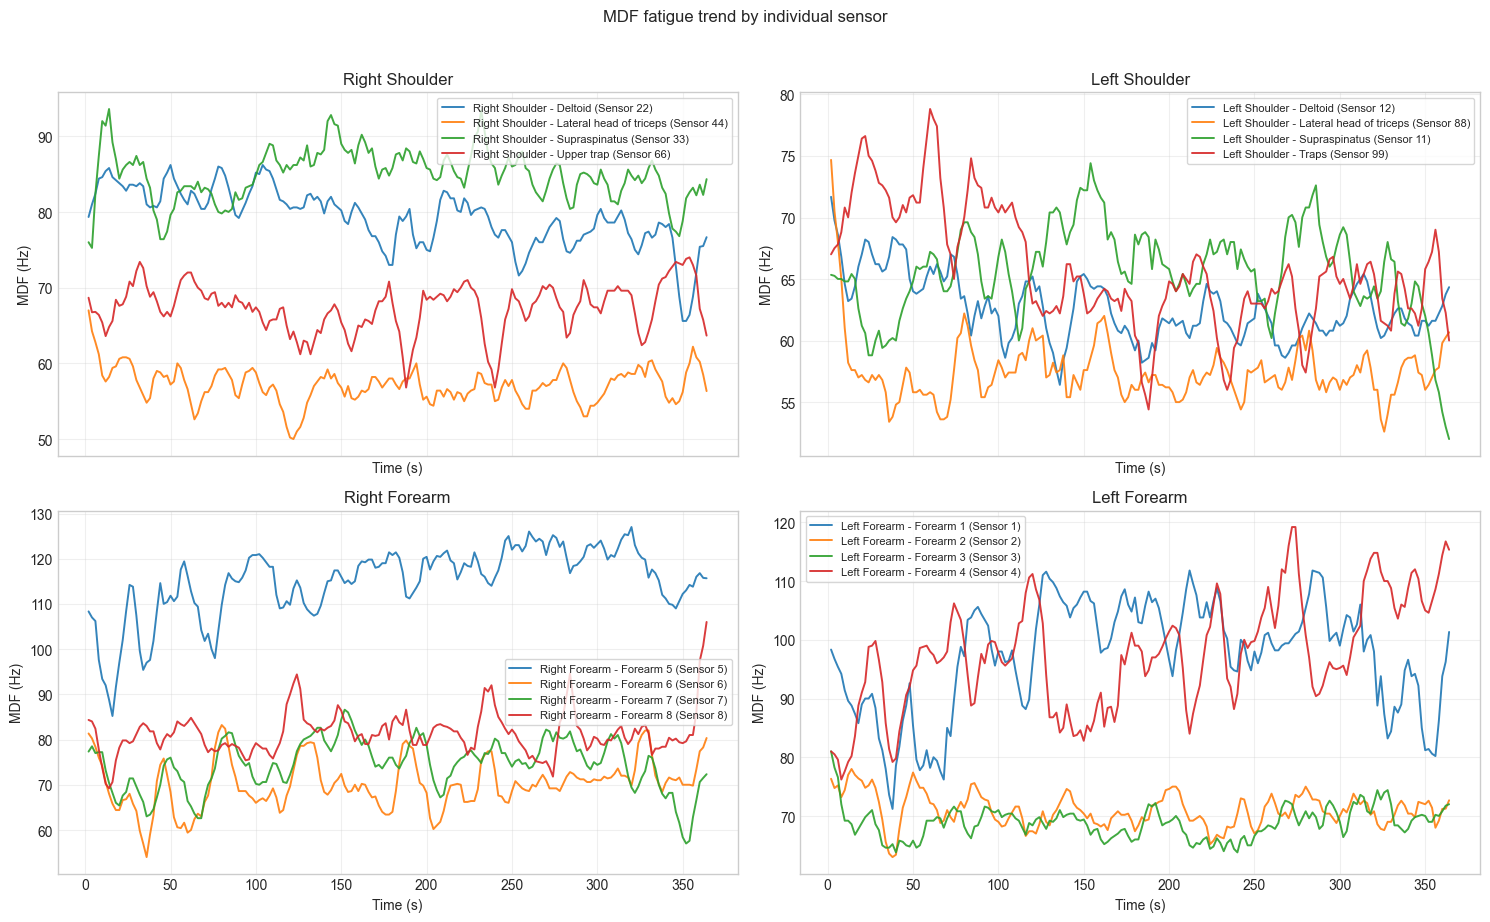

Saved: C:\Users\satgu\Documents\Code\2026-06-02\files-mentioned-by-the-user-avnish\outputs\emg_graph_outputs\fatigue_mnf_individual_sensors.png


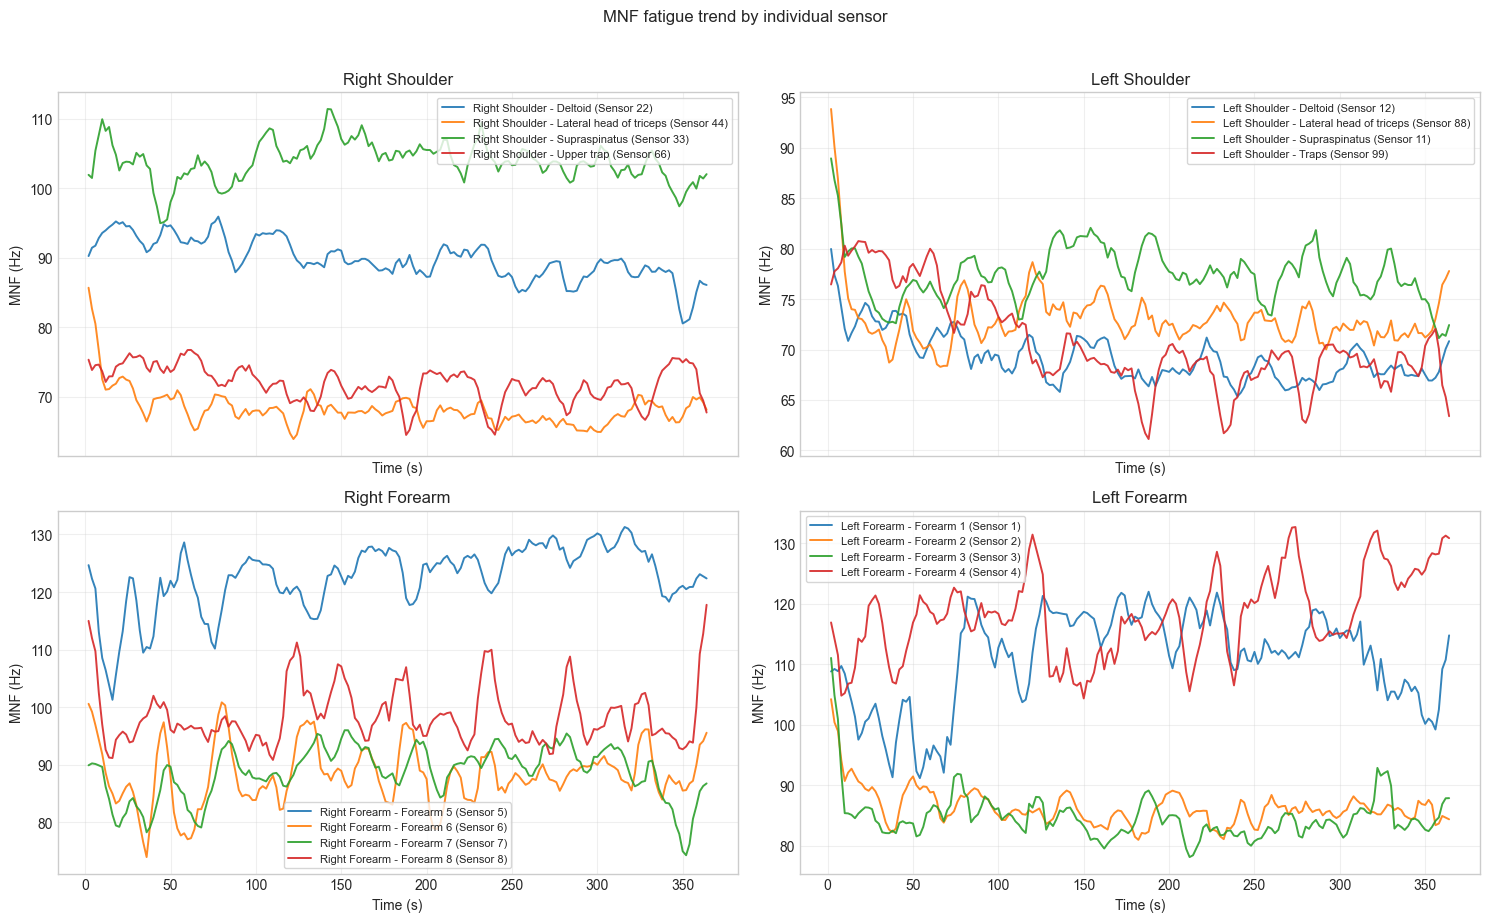

In [10]:
def smooth_series(series, window=5):
    return series.rolling(window, center=True, min_periods=1).mean()


def add_linear_trend(ax, x, y, color):
    valid = np.isfinite(x) & np.isfinite(y)
    if valid.sum() < 3:
        return
    slope, intercept = np.polyfit(x[valid], y[valid], 1)
    ax.plot(x[valid], slope * x[valid] + intercept, color=color, linestyle="--", linewidth=1.0, alpha=0.7)


def plot_overall_mdf_mnf_fatigue(fatigue_df):
    overall = (
        fatigue_df.assign(time_bin_s=lambda d: d["time_s"].round(1))
        .groupby("time_bin_s", as_index=False)[["mdf_hz", "mnf_hz"]]
        .mean()
        .sort_values("time_bin_s")
    )
    overall["mdf_smooth"] = smooth_series(overall["mdf_hz"], window=7)
    overall["mnf_smooth"] = smooth_series(overall["mnf_hz"], window=7)

    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.plot(overall["time_bin_s"], overall["mdf_smooth"], label="MDF", color="#1f77b4", linewidth=2.4)
    ax.plot(overall["time_bin_s"], overall["mnf_smooth"], label="MNF", color="#d62728", linewidth=2.4)
    add_linear_trend(ax, overall["time_bin_s"].to_numpy(), overall["mdf_smooth"].to_numpy(), "#1f77b4")
    add_linear_trend(ax, overall["time_bin_s"].to_numpy(), overall["mnf_smooth"].to_numpy(), "#d62728")

    ax.set_title("Push 1 fatigue trend: MDF and MNF decrease over time")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (Hz)")
    ax.legend(frameon=True)
    ax.grid(True, alpha=0.35)
    fig.tight_layout()

    output_path = OUTPUT_DIR / "fatigue_mdf_mnf_overall_trend.png"
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    print(f"Saved: {output_path}")
    plt.show()


def plot_group_fatigue(fatigue_df):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharex=True)
    metric_specs = [("mdf_hz", "MDF", "Median frequency (Hz)"), ("mnf_hz", "MNF", "Mean frequency (Hz)")]

    for ax, (metric_col, metric_label, y_label) in zip(axes, metric_specs):
        for group in GROUP_ORDER:
            group_data = fatigue_df[fatigue_df["group"] == group]
            if group_data.empty:
                continue

            trend = (
                group_data.assign(time_bin_s=lambda d: d["time_s"].round(1))
                .groupby("time_bin_s", as_index=False)[metric_col]
                .mean()
                .sort_values("time_bin_s")
            )
            trend["smooth"] = smooth_series(trend[metric_col], window=5)

            color = GROUP_COLORS.get(group)
            ax.plot(
                trend["time_bin_s"],
                trend["smooth"],
                label=group,
                linewidth=2.0,
                color=color,
            )
            add_linear_trend(ax, trend["time_bin_s"].to_numpy(), trend["smooth"].to_numpy(), color)

        ax.set_title(f"{metric_label} trend")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel(y_label)
        ax.grid(True, alpha=0.35)

    axes[0].legend(frameon=True, fontsize=9)
    fig.suptitle("Push 1 fatigue trend by group", y=1.02)
    fig.tight_layout()

    output_path = OUTPUT_DIR / "fatigue_mdf_mnf_group_trends.png"
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    print(f"Saved: {output_path}")
    plt.show()


def plot_individual_fatigue_facets(fatigue_df, metric_col="mdf_hz", metric_label="MDF"):
    fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True, sharey=False)
    axes = axes.ravel()

    for group in GROUP_ORDER:
        ax = axes[GROUP_ORDER.index(group)]
        group_data = fatigue_df[fatigue_df["group"] == group]
        for label, sensor_data in group_data.groupby("label"):
            sensor_data = sensor_data.sort_values("time_s")
            y = smooth_series(sensor_data[metric_col], window=5)
            ax.plot(sensor_data["time_s"], y, linewidth=1.4, alpha=0.9, label=label)

        ax.set_title(group)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel(f"{metric_label} (Hz)")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, frameon=True)

    fig.suptitle(f"{metric_label} fatigue trend by individual sensor", y=1.02)
    fig.tight_layout()

    output_path = OUTPUT_DIR / f"fatigue_{metric_label.lower()}_individual_sensors.png"
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    print(f"Saved: {output_path}")
    plt.show()


plot_overall_mdf_mnf_fatigue(fatigue_df)
plot_group_fatigue(fatigue_df)
plot_individual_fatigue_facets(fatigue_df, metric_col="mdf_hz", metric_label="MDF")
plot_individual_fatigue_facets(fatigue_df, metric_col="mnf_hz", metric_label="MNF")


In [11]:
def compute_baseline_rms(baseline_df, baseline_meta):
    rows = []
    for sensor_id in SENSORS_TO_ANALYZE:
        if sensor_id not in baseline_meta:
            continue
        time, filtered, fs = prepared_filtered_signal(baseline_df, baseline_meta, sensor_id)
        _, rms_values = windowed_rms(time, filtered, fs)
        rows.append(
            {
                "sensor": sensor_id,
                "label": sensor_label(sensor_id),
                "group": group_label(sensor_id),
                "baseline_rms_mV": np.nanmedian(rms_values),
            }
        )
    return pd.DataFrame(rows)


def mvc_source_for_sensor(sensor_id):
    side = SENSOR_MAP[str(sensor_id)]["side"]
    if side == "Left":
        return left_mvc_df, left_mvc_meta, "left_dynamo"
    if side == "Right":
        return right_mvc_df, right_mvc_meta, "right_dynamo"
    raise ValueError(f"Unknown side for sensor {sensor_id}")


def compute_mvc_reference_table(baseline_rms_df):
    baseline_lookup = baseline_rms_df.set_index("sensor")["baseline_rms_mV"].to_dict()
    rows = []

    for sensor_id in SENSORS_TO_ANALYZE:
        mvc_df, mvc_meta, source_name = mvc_source_for_sensor(sensor_id)
        if sensor_id not in mvc_meta:
            continue

        time, filtered, fs = prepared_filtered_signal(mvc_df, mvc_meta, sensor_id)
        _, rms_values = windowed_rms(time, filtered, fs)
        mvc_rms = np.nanmax(rms_values)
        baseline_rms = baseline_lookup.get(sensor_id, 0.0)
        corrected_mvc_rms = mvc_rms - baseline_rms

        if not np.isfinite(corrected_mvc_rms) or corrected_mvc_rms <= 0:
            corrected_mvc_rms = mvc_rms

        rows.append(
            {
                "sensor": sensor_id,
                "label": sensor_label(sensor_id),
                "group": group_label(sensor_id),
                "mvc_source": source_name,
                "baseline_rms_mV": baseline_rms,
                "mvc_rms_mV": mvc_rms,
                "mvc_minus_baseline_rms_mV": corrected_mvc_rms,
            }
        )

    return pd.DataFrame(rows)


def compute_percent_mvc_table(task_df, task_meta, mvc_reference_df):
    ref = mvc_reference_df.set_index("sensor")
    rows = []

    for sensor_id in SENSORS_TO_ANALYZE:
        if sensor_id not in task_meta or sensor_id not in ref.index:
            continue

        baseline_rms = ref.loc[sensor_id, "baseline_rms_mV"]
        mvc_corrected = ref.loc[sensor_id, "mvc_minus_baseline_rms_mV"]
        if not np.isfinite(mvc_corrected) or mvc_corrected <= 0:
            continue

        time, filtered, fs = prepared_filtered_signal(task_df, task_meta, sensor_id)
        centers, task_rms = windowed_rms(time, filtered, fs)
        task_corrected = np.maximum(task_rms - baseline_rms, 0.0)
        percent_mvc_raw = 100.0 * task_corrected / mvc_corrected
        percent_mvc = np.clip(percent_mvc_raw, 0.0, 100.0)

        sensor_rows = pd.DataFrame(
            {
                "time_s": centers,
                "sensor": sensor_id,
                "label": sensor_label(sensor_id),
                "muscle": SENSOR_MAP[sensor_id]["muscle"],
                "side": SENSOR_MAP[sensor_id]["side"],
                "region": SENSOR_MAP[sensor_id]["region"],
                "group": group_label(sensor_id),
                "task_rms_mV": task_rms,
                "task_minus_baseline_rms_mV": task_corrected,
                "percent_mvc_raw": percent_mvc_raw,
                "percent_mvc": percent_mvc,
                "exceeds_recorded_mvc": percent_mvc_raw > 100.0,
            }
        )
        rows.append(sensor_rows)

    return pd.concat(rows, ignore_index=True)


baseline_rms_df = compute_baseline_rms(baseline_df, baseline_meta)
mvc_reference_df = compute_mvc_reference_table(baseline_rms_df)
percent_mvc_df = compute_percent_mvc_table(task_df, task_meta, mvc_reference_df)

baseline_rms_df.to_csv(OUTPUT_DIR / "baseline_rms_by_sensor.csv", index=False)
mvc_reference_df.to_csv(OUTPUT_DIR / "mvc_reference_by_sensor.csv", index=False)
percent_mvc_df.to_csv(OUTPUT_DIR / "percent_mvc_timeseries.csv", index=False)

display(mvc_reference_df.round(5))


,sensor,label,group,mvc_source,baseline_rms_mV,mvc_rms_mV,mvc_minus_baseline_rms_mV
0,22,Right Shoulder - Deltoid (Sensor 22),Right Shoulder,right_dynamo,0.00281,0.08706,0.08425
1,44,Right Shoulder - Lateral head of triceps (Sens...,Right Shoulder,right_dynamo,0.00206,0.00466,0.00260
2,66,Right Shoulder - Upper trap (Sensor 66),Right Shoulder,right_dynamo,0.00383,0.03879,0.03496
3,33,Right Shoulder - Supraspinatus (Sensor 33),Right Shoulder,right_dynamo,0.00229,0.05080,0.04851
4,11,Left Shoulder - Supraspinatus (Sensor 11),Left Shoulder,left_dynamo,0.00444,0.09615,0.09171
5,12,Left Shoulder - Deltoid (Sensor 12),Left Shoulder,left_dynamo,0.00216,0.03084,0.02868
6,88,Left Shoulder - Lateral head of triceps (Senso...,Left Shoulder,left_dynamo,0.00184,0.00639,0.00456
7,99,Left Shoulder - Traps (Sensor 99),Left Shoulder,left_dynamo,0.00260,0.24338,0.24078
8,1,Left Forearm - Forearm 1 (Sensor 1),Left Forearm,left_dynamo,0.00159,0.06509,0.06350
9,2,Left Forearm - Forearm 2 (Sensor 2),Left Forearm,left_dynamo,0.00194,0.03527,0.03333


Saved: C:\Users\satgu\Documents\Code\2026-06-02\files-mentioned-by-the-user-avnish\outputs\emg_graph_outputs\percent_mvc_group_trend.png


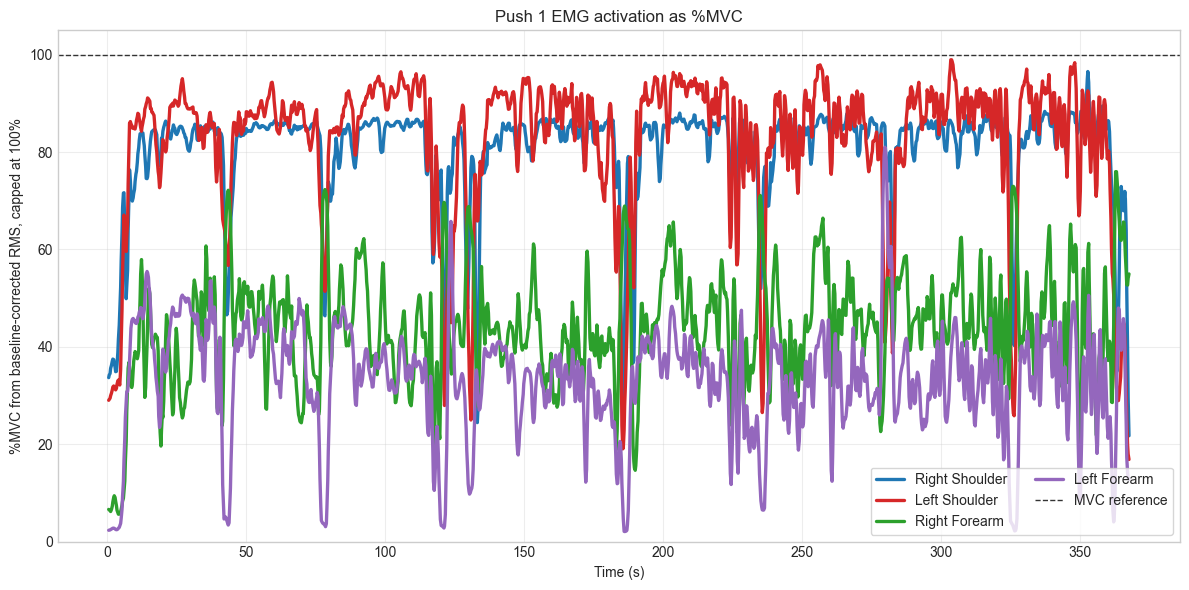

Saved: C:\Users\satgu\Documents\Code\2026-06-02\files-mentioned-by-the-user-avnish\outputs\emg_graph_outputs\percent_mvc_individual_sensors.png


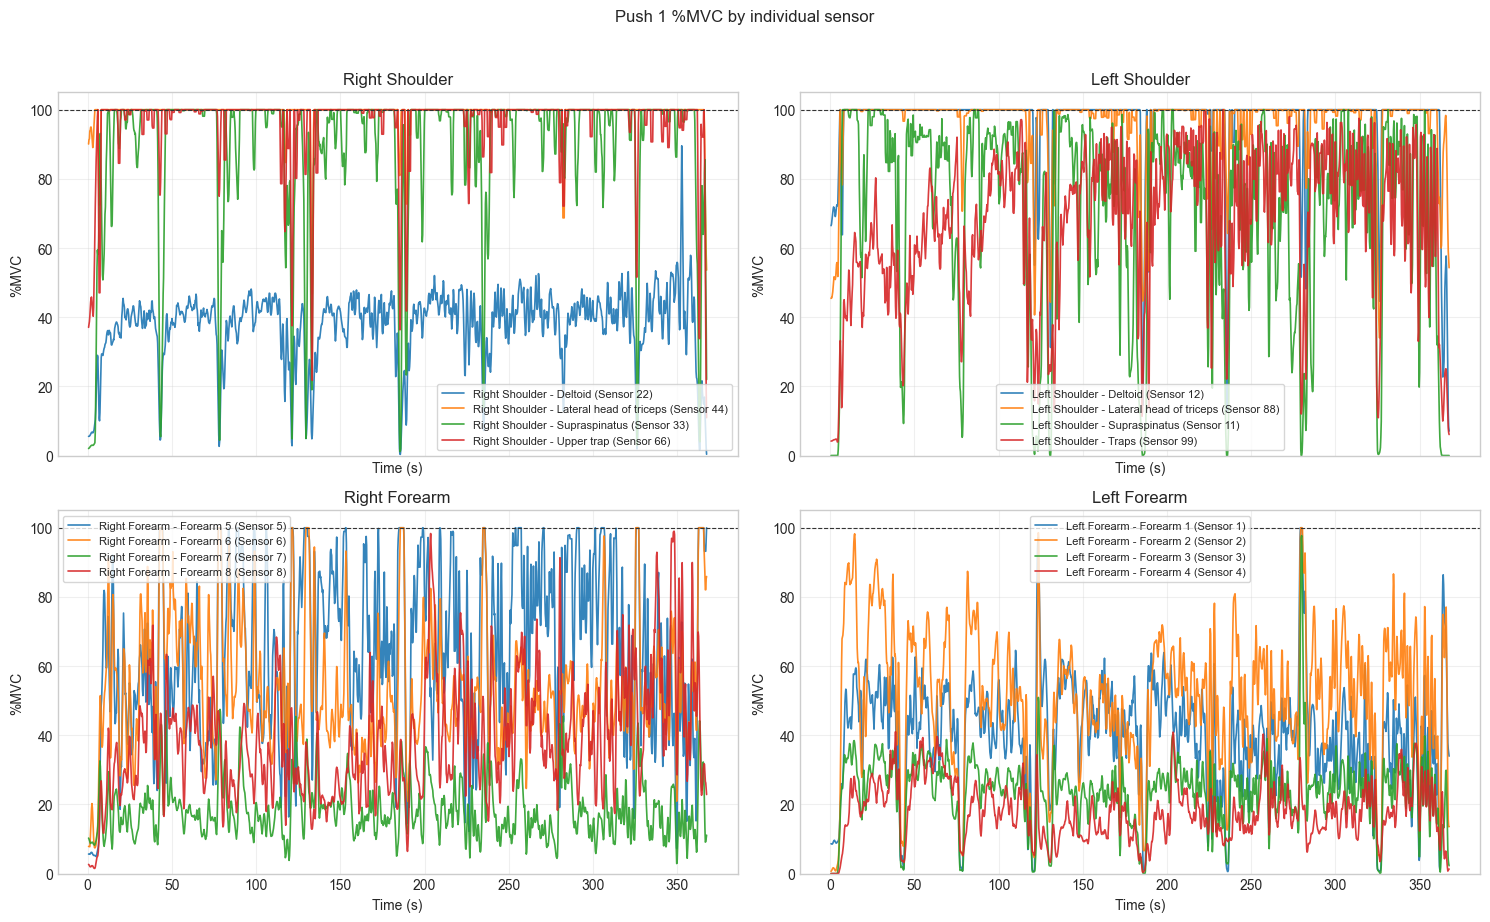

In [12]:
def plot_group_percent_mvc(percent_mvc_df):
    fig, ax = plt.subplots(figsize=(12, 6))

    for group in GROUP_ORDER:
        group_data = percent_mvc_df[percent_mvc_df["group"] == group]
        if group_data.empty:
            continue

        trend = (
            group_data.assign(time_bin_s=lambda d: d["time_s"].round(1))
            .groupby("time_bin_s", as_index=False)["percent_mvc"]
            .mean()
            .sort_values("time_bin_s")
        )
        trend["smooth"] = trend["percent_mvc"].rolling(5, center=True, min_periods=1).mean()
        ax.plot(
            trend["time_bin_s"],
            trend["smooth"],
            label=group,
            linewidth=2.4,
            color=GROUP_COLORS.get(group),
        )

    ax.axhline(100, color="#333333", linestyle="--", linewidth=1.0, label="MVC reference")
    ax.set_ylim(0, 105)
    ax.set_title("Push 1 EMG activation as %MVC")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("%MVC from baseline-corrected RMS, capped at 100%")
    ax.legend(frameon=True, ncols=2)
    ax.grid(True, alpha=0.35)
    fig.tight_layout()

    output_path = OUTPUT_DIR / "percent_mvc_group_trend.png"
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    print(f"Saved: {output_path}")
    plt.show()


def plot_individual_percent_mvc_facets(percent_mvc_df):
    fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True, sharey=False)
    axes = axes.ravel()

    for ax, group in zip(axes, GROUP_ORDER):
        group_data = percent_mvc_df[percent_mvc_df["group"] == group]
        for label, sensor_data in group_data.groupby("label"):
            sensor_data = sensor_data.sort_values("time_s")
            y = sensor_data["percent_mvc"].rolling(5, center=True, min_periods=1).mean()
            ax.plot(sensor_data["time_s"], y, linewidth=1.2, alpha=0.9, label=label)

        ax.axhline(100, color="#333333", linestyle="--", linewidth=0.8)
        ax.set_ylim(0, 105)
        ax.set_title(group)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("%MVC")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, frameon=True)

    fig.suptitle("Push 1 %MVC by individual sensor", y=1.02)
    fig.tight_layout()

    output_path = OUTPUT_DIR / "percent_mvc_individual_sensors.png"
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    print(f"Saved: {output_path}")
    plt.show()


plot_group_percent_mvc(percent_mvc_df)
plot_individual_percent_mvc_facets(percent_mvc_df)


In [13]:
# True analysis-window fatigue interpretation tables.
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

required_objects = ["fatigue_df", "percent_mvc_df", "OUTPUT_DIR"]
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(
        "Run the earlier analysis cells first. Missing objects: "
        + ", ".join(missing_objects)
    )

ROLLING_TREND_SECONDS = 60.0


def finite_median(values):
    values = pd.Series(values).dropna()
    return values.median() if len(values) else np.nan


def finite_iqr(values):
    values = pd.Series(values).dropna()
    if len(values) == 0:
        return np.nan
    return np.nanpercentile(values, 75) - np.nanpercentile(values, 25)


def slope_per_60s_from_arrays(time_s, values):
    time_s = np.asarray(time_s, dtype=float)
    values = np.asarray(values, dtype=float)
    valid = np.isfinite(time_s) & np.isfinite(values)
    if valid.sum() < 3:
        return np.nan
    return np.polyfit(time_s[valid] / 60.0, values[valid], 1)[0]


def rolling_slope_and_iqr(group, value_col, time_col="time_s", lookback_seconds=ROLLING_TREND_SECONDS):
    slopes = []
    iqrs = []
    times = group[time_col].to_numpy(dtype=float)
    values = group[value_col].to_numpy(dtype=float)

    for current_time in times:
        start_time = current_time - lookback_seconds
        mask = (times >= start_time) & (times <= current_time)
        slopes.append(slope_per_60s_from_arrays(times[mask], values[mask]))
        iqrs.append(finite_iqr(values[mask]))

    return pd.Series(slopes, index=group.index), pd.Series(iqrs, index=group.index)


def add_frequency_normalization_if_needed(fatigue_df):
    f = fatigue_df.copy()
    ref_seconds = globals().get("FATIGUE_REF_FIRST_SECONDS", 30.0)

    if "mdf_norm_pct" not in f.columns:
        refs = {}
        for label, group in f.groupby("label"):
            ref = finite_median(group.loc[group["time_s"] <= ref_seconds, "mdf_hz"])
            if not np.isfinite(ref) or ref == 0:
                ref = finite_median(group["mdf_hz"].head(5))
            refs[label] = ref
        f["mdf_norm_pct"] = f.apply(
            lambda row: 100.0 * row["mdf_hz"] / refs.get(row["label"], np.nan),
            axis=1,
        )

    if "mnf_norm_pct" not in f.columns:
        refs = {}
        for label, group in f.groupby("label"):
            ref = finite_median(group.loc[group["time_s"] <= ref_seconds, "mnf_hz"])
            if not np.isfinite(ref) or ref == 0:
                ref = finite_median(group["mnf_hz"].head(5))
            refs[label] = ref
        f["mnf_norm_pct"] = f.apply(
            lambda row: 100.0 * row["mnf_hz"] / refs.get(row["label"], np.nan),
            axis=1,
        )

    return f


def add_rms_normalization(percent_mvc_df):
    p = percent_mvc_df.copy()
    ref_seconds = globals().get("FATIGUE_REF_FIRST_SECONDS", 30.0)

    if "task_rms_mV" in p.columns:
        rms_col = "task_rms_mV"
    elif "task_minus_baseline_rms_mV" in p.columns:
        rms_col = "task_minus_baseline_rms_mV"
    else:
        rms_col = "percent_mvc"

    refs = {}
    for label, group in p.groupby("label"):
        ref = finite_median(group.loc[group["time_s"] <= ref_seconds, rms_col])
        if not np.isfinite(ref) or ref == 0:
            ref = finite_median(group[rms_col].head(20))
        refs[label] = ref

    p["rms_source_column"] = rms_col
    p["rms_norm_pct_first30"] = p.apply(
        lambda row: 100.0 * row[rms_col] / refs.get(row["label"], np.nan)
        if np.isfinite(refs.get(row["label"], np.nan)) and refs.get(row["label"], np.nan) != 0
        else np.nan,
        axis=1,
    )
    return p


def frequency_fatigue_state(avg_norm_pct):
    if not np.isfinite(avg_norm_pct):
        return "Not enough data"
    if avg_norm_pct <= 80:
        return "High fatigue level"
    if avg_norm_pct <= 90:
        return "Moderate fatigue level"
    if avg_norm_pct <= 95:
        return "Mild fatigue level"
    return "No clear fatigue level"


def frequency_change_from_previous(delta_avg_norm, avg_slope):
    if not np.isfinite(delta_avg_norm):
        return "First window for this muscle channel"
    if delta_avg_norm <= -2 or avg_slope <= -5:
        return "More fatigued than previous window"
    if delta_avg_norm >= 2 or avg_slope >= 5:
        return "Less fatigued/recovering versus previous window"
    return "Similar to previous window"


def rms_activation_state(percent_mvc):
    if not np.isfinite(percent_mvc):
        return "Not enough data"
    if percent_mvc >= 70:
        return "High activation"
    if percent_mvc >= 40:
        return "Moderate activation"
    return "Low activation"


def rms_change_from_previous(delta_rms_norm, delta_percent_mvc, rms_slope):
    values = [value for value in [delta_rms_norm, delta_percent_mvc] if np.isfinite(value)]
    avg_delta = np.nanmean(values) if values else np.nan
    if not np.isfinite(avg_delta):
        return "First window for this muscle channel"
    if avg_delta >= 2 or rms_slope >= 5:
        return "Activation increased versus previous window"
    if avg_delta <= -2 or rms_slope <= -5:
        return "Activation decreased versus previous window"
    return "Activation similar to previous window"


def frequency_explanation(row):
    muscle_label = row["muscle_label"] if "muscle_label" in row.index else row["label"]
    return (
        f'{row["window_start_s"]:.2f}-{row["window_end_s"]:.2f}s: '
        f'{muscle_label} has MDF {row["mdf_norm_pct"]:.1f}% and '
        f'MNF {row["mnf_norm_pct"]:.1f}% of early reference. '
        f'Change from previous avg frequency window: {row["avg_frequency_delta_from_previous_pct_points"]:+.1f} pct-points. '
        f'Rolling 60s slopes: MDF {row["mdf_slope_pct_per_60s"]:.2f}, '
        f'MNF {row["mnf_slope_pct_per_60s"]:.2f} pct-points/60s. '
        f'{row["fatigue_change_vs_previous"]}; {row["fatigue_level"]}.'
    )


def rms_explanation(row):
    muscle_label = row["muscle_label"] if "muscle_label" in row.index else row["label"]
    return (
        f'{row["window_start_s"]:.2f}-{row["window_end_s"]:.2f}s: '
        f'{muscle_label} has RMS {row["rms_norm_pct_first30"]:.1f}% of early RMS '
        f'and {row["percent_mvc"]:.1f}% MVC. '
        f'Change from previous RMS window: {row["rms_delta_from_previous_pct_points"]:+.1f} pct-points. '
        f'Rolling 60s RMS slope: {row["rms_slope_pct_per_60s"]:.2f} pct-points/60s; '
        f'IQR {row["rms_iqr_pct_rolling_60s"]:.1f}. '
        f'{row["activation_change_vs_previous"]}; {row["activation_level"]}.'
    )


def build_frequency_window_fatigue_table(fatigue_df):
    f = add_frequency_normalization_if_needed(fatigue_df)
    f = f.sort_values(["label", "time_s"]).copy()

    window_seconds = globals().get("FATIGUE_WINDOW_SECONDS", 4.0)
    f["window_center_s"] = f["time_s"].astype(float)
    f["window_start_s"] = np.maximum(0.0, f["window_center_s"] - window_seconds / 2.0)
    f["window_end_s"] = f["window_center_s"] + window_seconds / 2.0
    f["avg_frequency_norm_pct"] = f[["mdf_norm_pct", "mnf_norm_pct"]].mean(axis=1)

    output_parts = []
    for label, group in f.groupby("label", sort=False):
        group = group.sort_values("time_s").copy()
        group["mdf_delta_from_previous_pct_points"] = group["mdf_norm_pct"].diff()
        group["mnf_delta_from_previous_pct_points"] = group["mnf_norm_pct"].diff()
        group["avg_frequency_delta_from_previous_pct_points"] = group["avg_frequency_norm_pct"].diff()

        group["mdf_slope_pct_per_60s"], group["mdf_iqr_pct_rolling_60s"] = rolling_slope_and_iqr(
            group, "mdf_norm_pct"
        )
        group["mnf_slope_pct_per_60s"], group["mnf_iqr_pct_rolling_60s"] = rolling_slope_and_iqr(
            group, "mnf_norm_pct"
        )
        group["avg_frequency_slope_pct_per_60s"], group["avg_frequency_iqr_pct_rolling_60s"] = rolling_slope_and_iqr(
            group, "avg_frequency_norm_pct"
        )

        group["fatigue_level"] = group["avg_frequency_norm_pct"].apply(frequency_fatigue_state)
        group["fatigue_change_vs_previous"] = group.apply(
            lambda row: frequency_change_from_previous(
                row["avg_frequency_delta_from_previous_pct_points"],
                row["avg_frequency_slope_pct_per_60s"],
            ),
            axis=1,
        )
        group["fatigue_explanation"] = group.apply(frequency_explanation, axis=1)
        output_parts.append(group)

    table = pd.concat(output_parts, ignore_index=True)
    columns = [
        "sensor",
        "label",
        "side",
        "region",
        "muscle",
        "window_start_s",
        "window_center_s",
        "window_end_s",
        "mdf_norm_pct",
        "mnf_norm_pct",
        "avg_frequency_norm_pct",
        "mdf_delta_from_previous_pct_points",
        "mnf_delta_from_previous_pct_points",
        "avg_frequency_delta_from_previous_pct_points",
        "mdf_slope_pct_per_60s",
        "mnf_slope_pct_per_60s",
        "avg_frequency_slope_pct_per_60s",
        "mdf_iqr_pct_rolling_60s",
        "mnf_iqr_pct_rolling_60s",
        "avg_frequency_iqr_pct_rolling_60s",
        "mdf_hz",
        "mnf_hz",
        "fatigue_change_vs_previous",
        "fatigue_level",
        "fatigue_explanation",
    ]
    table = table[columns].rename(columns={"label": "muscle_label"})
    numeric_cols = table.select_dtypes(include=[np.number]).columns
    table[numeric_cols] = table[numeric_cols].round(2)
    return table.sort_values(["sensor", "window_center_s"]).reset_index(drop=True)


def build_rms_window_fatigue_table(percent_mvc_df):
    p = add_rms_normalization(percent_mvc_df)
    p = p.sort_values(["label", "time_s"]).copy()

    window_seconds = globals().get("RMS_WINDOW_SECONDS", 1.0)
    p["window_center_s"] = p["time_s"].astype(float)
    p["window_start_s"] = np.maximum(0.0, p["window_center_s"] - window_seconds / 2.0)
    p["window_end_s"] = p["window_center_s"] + window_seconds / 2.0

    output_parts = []
    for label, group in p.groupby("label", sort=False):
        group = group.sort_values("time_s").copy()
        group["rms_delta_from_previous_pct_points"] = group["rms_norm_pct_first30"].diff()
        group["percent_mvc_delta_from_previous_pct_points"] = group["percent_mvc"].diff()
        group["rms_slope_pct_per_60s"], group["rms_iqr_pct_rolling_60s"] = rolling_slope_and_iqr(
            group, "rms_norm_pct_first30"
        )
        group["percent_mvc_slope_pct_per_60s"], group["percent_mvc_iqr_rolling_60s"] = rolling_slope_and_iqr(
            group, "percent_mvc"
        )
        group["activation_level"] = group["percent_mvc"].apply(rms_activation_state)
        group["activation_change_vs_previous"] = group.apply(
            lambda row: rms_change_from_previous(
                row["rms_delta_from_previous_pct_points"],
                row["percent_mvc_delta_from_previous_pct_points"],
                row["rms_slope_pct_per_60s"],
            ),
            axis=1,
        )
        group["rms_mvc_explanation"] = group.apply(rms_explanation, axis=1)
        output_parts.append(group)

    table = pd.concat(output_parts, ignore_index=True)
    columns = [
        "sensor",
        "label",
        "side",
        "region",
        "muscle",
        "window_start_s",
        "window_center_s",
        "window_end_s",
        "rms_norm_pct_first30",
        "percent_mvc",
        "percent_mvc_raw",
        "rms_delta_from_previous_pct_points",
        "percent_mvc_delta_from_previous_pct_points",
        "rms_slope_pct_per_60s",
        "percent_mvc_slope_pct_per_60s",
        "rms_iqr_pct_rolling_60s",
        "percent_mvc_iqr_rolling_60s",
        "task_rms_mV",
        "rms_source_column",
        "activation_change_vs_previous",
        "activation_level",
        "rms_mvc_explanation",
    ]
    existing_columns = [col for col in columns if col in table.columns]
    table = table[existing_columns].rename(columns={"label": "muscle_label"})
    numeric_cols = table.select_dtypes(include=[np.number]).columns
    table[numeric_cols] = table[numeric_cols].round(2)
    return table.sort_values(["sensor", "window_center_s"]).reset_index(drop=True)


frequency_window_fatigue_table = build_frequency_window_fatigue_table(fatigue_df)
rms_window_fatigue_table = build_rms_window_fatigue_table(percent_mvc_df)

frequency_window_fatigue_table.to_csv(OUTPUT_DIR / "frequency_true_window_fatigue_table.csv", index=False)
rms_window_fatigue_table.to_csv(OUTPUT_DIR / "rms_true_window_fatigue_table.csv", index=False)


In [14]:
display(Markdown("#### MDF/MNF true-window fatigue table"))
display(frequency_window_fatigue_table)

frequency_window_fatigue_table.to_csv(
    OUTPUT_DIR / "frequency_true_window_fatigue_table.csv",
    index=False
)
frequency_window_fatigue_table.to_excel(
    OUTPUT_DIR / "frequency_true_window_fatigue_table.xlsx",
    index=False
)

print("Saved:", OUTPUT_DIR / "frequency_true_window_fatigue_table.csv")
print("Saved:", OUTPUT_DIR / "frequency_true_window_fatigue_table.xlsx")

#### MDF/MNF true-window fatigue table

,sensor,muscle_label,side,region,muscle,window_start_s,window_center_s,window_end_s,mdf_norm_pct,mnf_norm_pct,...,mnf_slope_pct_per_60s,avg_frequency_slope_pct_per_60s,mdf_iqr_pct_rolling_60s,mnf_iqr_pct_rolling_60s,avg_frequency_iqr_pct_rolling_60s,mdf_hz,mnf_hz,fatigue_change_vs_previous,fatigue_level,fatigue_explanation
0,1,Left Forearm - Forearm 1 (Sensor 1),Left,Forearm,Forearm 1,0.00,2.00,4.00,107.69,100.29,...,NaN,NaN,0.00,0.00,0.00,98.02,106.25,First window for this muscle channel,No clear fatigue level,0.00-4.00s: Left Forearm - Forearm 1 (Sensor 1...
1,1,Left Forearm - Forearm 1 (Sensor 1),Left,Forearm,Forearm 1,2.00,4.00,6.00,107.69,100.47,...,NaN,NaN,0.00,0.09,0.05,98.02,106.45,Similar to previous window,No clear fatigue level,2.00-6.00s: Left Forearm - Forearm 1 (Sensor 1...
2,1,Left Forearm - Forearm 1 (Sensor 1),Left,Forearm,Forearm 1,4.00,6.00,8.00,108.79,107.26,...,104.54,60.51,0.55,3.49,2.02,99.02,113.64,Less fatigued/recovering versus previous window,No clear fatigue level,4.00-8.00s: Left Forearm - Forearm 1 (Sensor 1...
3,1,Left Forearm - Forearm 1 (Sensor 1),Left,Forearm,Forearm 1,6.00,8.00,10.00,101.10,104.22,...,55.76,-0.13,1.92,4.56,1.41,92.02,110.42,More fatigued than previous window,No clear fatigue level,6.00-10.00s: Left Forearm - Forearm 1 (Sensor ...
4,1,Left Forearm - Forearm 1 (Sensor 1),Left,Forearm,Forearm 1,8.00,10.00,12.00,98.90,101.39,...,17.89,-27.31,6.59,3.75,1.42,90.02,107.43,More fatigued than previous window,No clear fatigue level,8.00-12.00s: Left Forearm - Forearm 1 (Sensor ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2907,99,Left Shoulder - Traps (Sensor 99),Left,Shoulder,Traps,354.07,356.07,358.07,94.44,89.71,...,1.07,0.35,6.25,4.30,4.27,68.01,71.13,More fatigued than previous window,Mild fatigue level,354.07-358.07s: Left Shoulder - Traps (Sensor ...
2908,99,Left Shoulder - Traps (Sensor 99),Left,Shoulder,Traps,356.07,358.07,360.07,95.83,89.55,...,2.03,1.98,6.25,4.31,4.27,69.01,71.01,Similar to previous window,Mild fatigue level,356.07-360.07s: Left Shoulder - Traps (Sensor ...
2909,99,Left Shoulder - Traps (Sensor 99),Left,Shoulder,Traps,358.07,360.07,362.07,97.22,90.08,...,3.07,3.78,6.25,4.39,4.27,70.01,71.43,Similar to previous window,Mild fatigue level,358.07-362.07s: Left Shoulder - Traps (Sensor ...
2910,99,Left Shoulder - Traps (Sensor 99),Left,Shoulder,Traps,360.07,362.07,364.07,79.17,77.93,...,0.89,1.05,6.25,4.39,4.27,57.01,61.79,More fatigued than previous window,High fatigue level,360.07-364.07s: Left Shoulder - Traps (Sensor ...


Saved: C:\Users\satgu\Documents\Code\2026-06-02\files-mentioned-by-the-user-avnish\outputs\emg_graph_outputs\frequency_true_window_fatigue_table.csv
Saved: C:\Users\satgu\Documents\Code\2026-06-02\files-mentioned-by-the-user-avnish\outputs\emg_graph_outputs\frequency_true_window_fatigue_table.xlsx


In [16]:
display(Markdown("#### RMS/%MVC true-window activation table"))
display(rms_window_fatigue_table)
print("Saved:", OUTPUT_DIR / "rms_true_window_fatigue_table.csv")


#### RMS/%MVC true-window activation table

,sensor,muscle_label,side,region,muscle,window_start_s,window_center_s,window_end_s,rms_norm_pct_first30,percent_mvc,...,percent_mvc_delta_from_previous_pct_points,rms_slope_pct_per_60s,percent_mvc_slope_pct_per_60s,rms_iqr_pct_rolling_60s,percent_mvc_iqr_rolling_60s,task_rms_mV,rms_source_column,activation_change_vs_previous,activation_level,rms_mvc_explanation
0,1,Left Forearm - Forearm 1 (Sensor 1),Left,Forearm,Forearm 1,0.00,0.50,1.00,23.28,8.91,...,NaN,NaN,NaN,0.00,0.00,0.01,task_rms_mV,First window for this muscle channel,Low activation,0.00-1.00s: Left Forearm - Forearm 1 (Sensor 1...
1,1,Left Forearm - Forearm 1 (Sensor 1),Left,Forearm,Forearm 1,0.25,0.75,1.25,22.70,8.62,...,-0.28,NaN,NaN,0.29,0.14,0.01,task_rms_mV,Activation similar to previous window,Low activation,0.25-1.25s: Left Forearm - Forearm 1 (Sensor 1...
2,1,Left Forearm - Forearm 1 (Sensor 1),Left,Forearm,Forearm 1,0.50,1.00,1.50,22.23,8.39,...,-0.23,-125.69,-61.61,0.52,0.26,0.01,task_rms_mV,Activation decreased versus previous window,Low activation,0.50-1.50s: Left Forearm - Forearm 1 (Sensor 1...
3,1,Left Forearm - Forearm 1 (Sensor 1),Left,Forearm,Forearm 1,0.75,1.25,1.75,21.90,8.23,...,-0.16,-110.24,-54.04,0.70,0.34,0.01,task_rms_mV,Activation decreased versus previous window,Low activation,0.75-1.75s: Left Forearm - Forearm 1 (Sensor 1...
4,1,Left Forearm - Forearm 1 (Sensor 1),Left,Forearm,Forearm 1,1.00,1.50,2.00,22.76,8.65,...,0.42,-43.95,-21.54,0.53,0.26,0.01,task_rms_mV,Activation decreased versus previous window,Low activation,1.00-2.00s: Left Forearm - Forearm 1 (Sensor 1...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23483,99,Left Shoulder - Traps (Sensor 99),Left,Shoulder,Traps,365.96,366.46,366.96,26.59,12.40,...,-10.56,-71.05,-30.05,136.38,67.17,0.03,task_rms_mV,Activation decreased versus previous window,Low activation,365.96-366.96s: Left Shoulder - Traps (Sensor ...
23484,99,Left Shoulder - Traps (Sensor 99),Left,Shoulder,Traps,366.21,366.71,367.21,18.80,8.45,...,-3.95,-72.84,-30.76,136.83,67.40,0.02,task_rms_mV,Activation decreased versus previous window,Low activation,366.21-367.21s: Left Shoulder - Traps (Sensor ...
23485,99,Left Shoulder - Traps (Sensor 99),Left,Shoulder,Traps,366.46,366.96,367.46,17.40,7.75,...,-0.71,-74.58,-31.45,137.17,67.57,0.02,task_rms_mV,Activation decreased versus previous window,Low activation,366.46-367.46s: Left Shoulder - Traps (Sensor ...
23486,99,Left Shoulder - Traps (Sensor 99),Left,Shoulder,Traps,366.72,367.22,367.72,15.18,6.62,...,-1.13,-76.40,-32.18,138.03,68.01,0.02,task_rms_mV,Activation decreased versus previous window,Low activation,366.72-367.72s: Left Shoulder - Traps (Sensor ...


Saved: C:\Users\satgu\Documents\Code\2026-06-02\files-mentioned-by-the-user-avnish\outputs\emg_graph_outputs\rms_true_window_fatigue_table.csv
